# Lab 2 Solutions

# Part I: The Verlet method applied to the Kepler problem

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from tqdm import tqdm

def kepler_analytic(vel,T):

    #-------------------------------------------------------------------------------
    # Calculate the analytic trajectory for the Kepler central force problem.
    # Assumes an initial position r = (1,0), v = (0,vel).
    #-------------------------------------------------------------------------------
    # INPUTS:
    # - vel: the initial speed.
    # - T: sets an upper limit for |theta| for the e > 1 case (plot up to the
    #        integration time).
    #-------------------------------------------------------------------------------

    # Calculate trajectory from analytic solution

    ecc = np.linalg.norm(vel)**2 - 1        # Eccentricity
    a = 1/(1 - ecc)                         # Semi-major axis

    if ecc < 1:

        theta = np.linspace(0, 2*np.pi, 50) # Equally spaced values from 0 to 2*pi
        b = a * np.sqrt(1 - ecc**2)
        xan = -a * ecc + a * np.cos(theta)
        yan =  b * np.sin(theta)

    else:

        b = a * np.sqrt(ecc**2 - 1)
        theta_max = np.arcsinh(np.linalg.norm(vel) * T/b) # Limit for range of theta
        theta = np.linspace( -theta_max, theta_max, 50)
        xan = - a * ecc + a * np.cosh(theta)
        yan =   b * np.sinh(theta)

    return xan, yan


## <span style="color:red">Q1</span>
### Run the code from the lecture (kepler_verlet.ipynb or kepler_dynamic.ipynb) for the initial non-dimensional velocities \($v_1$ = 0.3, 0.9, 1, 1.2, 1.3, 1.5\). For the first case you will need to reduce the time step from the default value (\$\tau$=0.05\, in non-dimensional units) to obtain a reasonably accurate integration. It may be helpful to consider changes in the time step through factors of 5 or 10. What are some valid indicators that your results are accurate?

## <span style="color:red">Answer</span>

Change these initial conditions in the code as instructed, and study the differences in behaviour!

`# Time step (non-dim.)`

`tau = 0.05`

`# Initial velocity (non-dim.) `

`vel = np.array([0, 1.5])`

`# Total integration time`

`T = 4*np.pi`

For $v_1$ = 0.3, the orbit diverges with the default time step ($\tau$ = 0.05). Reducing the time step to
$\tau$ = 0.005 leads to precession; a time step $\tau$ = 0.0005 gives a reasonably accurate integration.
For the other cases the default time step gives an orbit which is fairly accurate. The evidence for
this is that the analytic orbit is reproduced reasonably well, and the energy varies only by a
fraction of a percent. Of course, there is no absolute measure of accuracy

## <span style="color:red">Q2</span>
### Obtain accurate orbits for the cases  \($v_1$=0.3, 0.9, 1, 1.2, 1.3, 1.5\).




Match each case with the most accurate description of its orbit.




Note that the 'near' focus refers to being nearer the initial condition and a 'far' focus refers to one farther from the initial condition.

## <span style="color:red">Answer</span>

For $v_1 = 0.3$ the orbit is an ellipse with the Sun at the far focus (since $v_1 < 1$).

For $v_1 = 0.9$ the orbit is an ellipse with the Sun at the far focus (since $v_1 < 1$).

For $v_1 = 1$ the orbit is a circle with the Sun at the centre.

For $v_1 = 1.2$ the orbit is an ellipse with the Sun at the near focus (since $1 < v_1 < \sqrt{2}$).

For $v_1 = 1.3$ the orbit is a highly eccentric ellipse with the Sun at the near focus (since $1 < v_1 < \sqrt{2}$).

For $v_1 = 1.5$ the orbit is a hyperbola (since $v_1 > \sqrt{2}$).

## <span style="color:red">Q3</span>
### Without changing the numerical integration, modify Verlet method code to store the speed and the distance from the Sun at each time step as a vector, in the same way that the code stores the energy at each time step.


For the initial conditions `r_1=[1,0]`, and `v_1=[0,0.7]`
together with the total integration time `T=10` and time step `tau=0.01`, plot the speed and distance as a function of time.


Notice the distance from the sun at which the speed is a maximum/minimum.


Produce a single plot with your results, save it as an image, and upload it below.

## <span style="color:red">Answer</span>

We can store variables through the loop by preallocating before the loop

```python
dist = np.zeros(numSteps)
speed = np.zeros(numSteps)
```

and then storing values at each iteration of the loop:

```python
# Store distance and speed
dist[n] = r
speed[n] = norm[vel]
```

Then after the loop we can plot the result. To get the requested result, we need to set vel = [0, 0.7], T = 10, tau = 0.01.

The modified code and the correct figure are as follows:


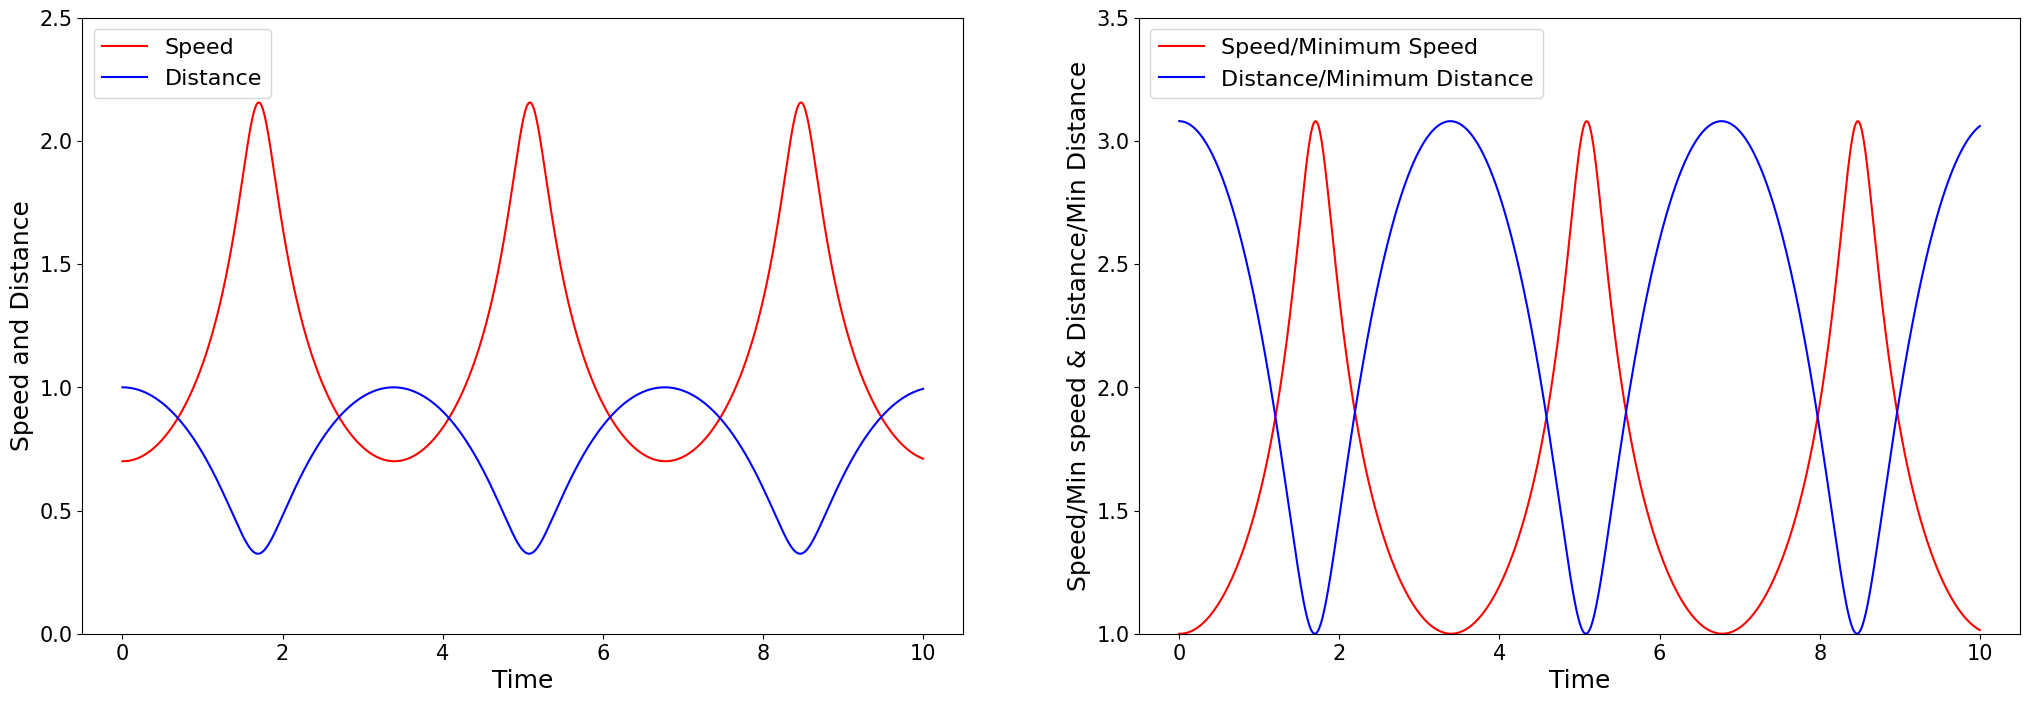

In [2]:
### !!! Change initial conditions !!! ###


# Time step (non-dim.)
tau = 0.01

# Initial position (non-dim.) 
pos = np.array([1, 0])

# Initial velocity (non-dim.) 
vel = np.array([0, 0.7])

# Total integration time
T = 10

# Number of integration steps
numSteps = int(np.ceil(T/tau))

# Calculate trajectory from analytic solution.
xan, yan = kepler_analytic(vel, T)

# Preallocate vectors for speed:
time = tau*np.arange(numSteps+1)
x = np.zeros(numSteps+1)
y = np.zeros(numSteps+1)
energy = np.zeros(numSteps+1)

# Initial values:
x[0] = pos[0]
y[0] = pos[1]
r = np.linalg.norm(pos)
accel = -pos/r**3

# !!! Change here !!! #
dist = np.zeros(numSteps+1)
speed = np.zeros(numSteps+1)

dist[0] = r
speed[0] = np.linalg.norm(vel)
# !!!             !!! #

energy[0] = 0.5*speed[0]**2 - 1/r

#-------------------------------------------------------------------------------
# Verlet method integration
#-------------------------------------------------------------------------------

prev = np.zeros_like(pos)
next_pos = np.zeros_like(pos)


for n in range(numSteps):

    # Take one step of the Verlet Method to update position:
    if n==0:
        # Get started with a midpoint method step
        next_pos = pos + tau*vel + 0.5*tau**2*accel
    else:
        # Normal Verlet update:
        next_pos = 2*pos - prev + tau**2*accel

    # Take one step of the Verlet Method to update velocity
    # (only required to compute energy, not the trajectory)
    if n==0:
        # Do a special (Velocity-Verlet) update for the very first step:
        r = np.linalg.norm(next_pos)
        accel_n2 = -next_pos/r**3
        vel = vel + tau/2*(accel + accel_n2)
    else: # n > 1
        # Do a Verlet update:
        vel = (next_pos - prev)/(2*tau)

    # Calculate speed, radial position, and acceleration after taking the step:

    r = np.linalg.norm(next_pos)
    accel = -next_pos/r**3
    
    # !!! Change here !!! #
    dist[n+1] = r
    speed[n+1] = np.linalg.norm(vel)
    # !!!             !!! #

    # Update energy after taking the step:
    energy[n+1] = 0.5*speed[n+1]**2 - 1/r

    # Store position update:
    x[n+1] = next_pos[0]
    y[n+1] = next_pos[1]

    # Update 'prev' and 'pos' to calculate 'next_pos' in the following step:
    prev = pos
    pos = next_pos
    
    
    
# !!! Now, plot the figure !!!



# Set up figure
    
fig, ax = plt.subplots(1,2, figsize=(25,8))

# Left plot:

ax[0].plot(time, speed, '-r', label='Speed')
ax[0].plot(time, dist, '-b', label='Distance')


ax[0].tick_params(labelsize=15)
ax[0].set(ylim=[0,2.5])
ax[0].set_xlabel("Time", fontsize=18);
ax[0].set_ylabel("Speed and Distance", fontsize=18)

ax[0].legend(fontsize=16, loc='upper left')

# Right plot 

ax[1].plot(time,speed/min(speed), '-r', label='Speed/Minimum Speed')
ax[1].plot(time, dist/min(dist), '-b', label='Distance/Minimum Distance')


ax[1].tick_params(labelsize=15)
ax[1].set(ylim=[1,3.5])
ax[1].set_xlabel("Time", fontsize=18);
ax[1].set_ylabel("Speed/Min speed & Distance/Min Distance", fontsize=18)

ax[1].legend(fontsize=16, loc='upper left');
plt.show()


**Marking notes:** 

1 point if the plot on the left is provided, with correct labels and scales 

0.75 points if minor issue, e.g., units of time are given (the system is non-dimensionalised)

0.5 points for correct dynamics, but multiple issues with labels

0 points if dynamics are incorrect or no figure uploaded

## <span style="color:red">Q4</span>
### Use the min and max functions to compute the ratio of the maximum to the minimum speed, and the ratio of the maximum to the minimum distance, for your results for Part 3 above.


You should find that 
$$\frac{v_{\rm max}}{v_{\rm min}}=\frac{r_{\rm max}}{r_{\rm min}}.$$

If you do not find this, there is an error in your code.

What is the ratio 
$$R=\frac{v_{\rm max}}{v_{\rm min}}=\frac{r_{\rm max}}{r_{\rm min}}?$$


## <span style="color:red">Answer</span>

We can calculate the maximum to minimum ratios for the distance and speed, based on the stored values:

In [5]:
print('Vmax/Vmin: ', f"{(max(speed)/min(speed)):.2f}")
print('Dmax/Dmin: ', f"{(max(dist)/min(dist)):.2f}")

Vmax/Vmin:  3.08
Dmax/Dmin:  3.08


The ratios are about about 3.08 in each case.

As we found in Question 3:
* the speed at perihelion is a maximum and the speed at aphelion is a minimum, and
* the distance at perihelion is a minimum and the distance at aphelion is a maximum.

These results show that $v_p/v_a = r_a/r_p$, or $r_a v_a = r_p v_p$, which is Kepler's second law.

## <span style="color:red">Q5</span>
### The angular momentum of the planet or comet is ${\bf L}={\bf r}\times m{\bf v}$. This quantity is constant during the motion because the force on the planet or comet is radially inwards, which means the torque, $\tau = {\bf r} \times {\bf F} = 0$.
 
The magnitude of the angular momentum is $L=mvr\sin\phi,$ where $\phi$ is the angle between ${\bf v}$ and ${\bf r}$.
 
By considering the angular momentum at perihelion and aphelion (closest and furthest approach from the Sun), prove that
$$v_{\rm max}/v_{\rm min}=r_{\rm max}/r_{\rm min}.$$ 
 
**Write a few line proof.**

## <span style="color:red">Answer</span>

The gravitation force always points in the same direction as the position vector, r, so there is no torque and angular momentum is conserved.

Conservation of angular momentum implies that

$$|r_a \times mv_a| = |r_p \times mv_p|.$$

At perihelion and aphelion the radius and velocity vectors are perpendicular, so this gives
$r_av_a = r_pv_p$.

**Marking notes**
   
- 2 points for full explanation and workings
   
- 1 point if workings are present but explanations are incomplete

- 0 points if working/explanation incorrect

# <span style="color:k">Part II: Halley's Comet</span>
## <span style="color:red">Q6</span>
### Using the analytic solution to the Kepler problem (see the Appendix to the lecture notes from this week), and assuming non-dimensional initial conditions ${\bf r}_1=(1,0)$, ${\bf v}_1=(0,v_1)$, determine the value of $v_1$ corresponding to an orbit with $a=17.834$.  

Hint: As in the lecture notes, for an elliptical orbit we have eccentricity $e = v_1^2 - 1$ and semi-major axis $a = \frac{1}{1-e}$.

Note: Give your answer for $v_1$ to at least two decimal places below.

Hint: It will be helpful to retain your calculation for $v_1$ to full precision to obtain accurate answers for the subsequent calculations (below).

## <span style="color:red">Answer</span>

From the formulae for elliptic orbits, we have $v_1 = \sqrt{2-1/a}$, so for $a = 17.834$:

In [4]:
a = 17.834
v1 = np.sqrt(2-1/a)

print('v1 =', f"{v1:.4f}")

v1 = 1.3942


## <span style="color:red">Q7</span>
### Modify the code Verlet method code to integrate the equations of motion for the initial conditions in 6. Choose a suitable value of $\tau$ for an accurate numerical solution, and a value of the total integration time $T$ which encompasses one period. (*Note*: You will require a large number of integration steps.)
 
Estimate the non-dimensional period $P$ of the motion based on your numerical results. 
 
*Suggestion:* One way to estimate the period is from the plot of total energy versus time. From the Matlab figure, you can identify the period based on the dip in estimated energy associated with closest approach to the Sun (perihelion). 
 
**Write your answer as a number (to at least three significant figures).**

## <span style="color:red">Answer</span>

Here we can set our parameters (using trial and error to find a `T` long enough to capture a period):

```python
tau = 0.001
vel = [0, np.sqrt(2-1/a)]
T = 500
```

We can estimate the point at which the comet returns using the dip in (estimated) energy (at a
phase of the orbit where the comet is moving rapidly and thus is hard to accurately resolve).
This can be computed visually from the energy-time plot, or using

```python
emin = np.min(energy)
imin = np.argmin(energy)
Pest = time[imin]
print(f'Estimate for period (non-dimensional): {Pest:.3f}')
```

In [5]:
### !!! Change initial conditions !!! ###


# Time step (non-dim.)
tau = 0.001

# Initial position (non-dim.) 
pos = np.array([1, 0])

# Initial velocity (non-dim.) 
vel = np.array([0, np.sqrt(2-1/a)])

# Total integration time
T = 500

# Number of integration steps
numSteps = int(np.ceil(T/tau))

# Calculate trajectory from analytic solution.
xan, yan = kepler_analytic(vel, T)

# Preallocate vectors for speed:
time = tau*np.arange(numSteps+1)
x = np.zeros(numSteps+1)
y = np.zeros(numSteps+1)
energy = np.zeros(numSteps+1)

# Initial values:
x[0] = pos[0]
y[0] = pos[1]
r = np.linalg.norm(pos)
accel = -pos/r**3

# !!! Change here !!! #
dist = np.zeros(numSteps+1)
speed = np.zeros(numSteps+1)

dist[0] = r
speed[0] = np.linalg.norm(vel)

# !!!             !!! #

energy[0] = 0.5*speed[0]**2 - 1/r

#-------------------------------------------------------------------------------
# Verlet method integration
#-------------------------------------------------------------------------------

prev = np.zeros_like(pos)
next_pos = np.zeros_like(pos)


for n in range(numSteps):

    # Take one step of the Verlet Method to update position:
    if n==0:
        # Get started with a midpoint method step
        next_pos = pos + tau*vel + 0.5*tau**2*accel
    else:
        # Normal Verlet update:
        next_pos = 2*pos - prev + tau**2*accel

    # Take one step of the Verlet Method to update velocity
    # (only required to compute energy, not the trajectory)
    if n==0:
        # Do a special (Velocity-Verlet) update for the very first step:
        r = np.linalg.norm(next_pos)
        accel_n2 = -next_pos/r**3
        vel = vel + tau/2*(accel + accel_n2)
    else: # n > 1
        # Do a Verlet update:
        vel = (next_pos - prev)/(2*tau)

    # Calculate speed, radial position, and acceleration after taking the step:

    r = np.linalg.norm(next_pos)
    accel = -next_pos/r**3

    # Update energy after taking the step:
    energy[n+1] = 0.5*speed[n+1]**2 - 1/r

    # Store position update:
    x[n+1] = next_pos[0]
    y[n+1] = next_pos[1]

    # Update 'prev' and 'pos' to calculate 'next_pos' in the following step:
    prev = pos
    pos = next_pos
    
    
## !!! Find esitmate for period !!! ##    
        
emin = np.min(energy)
imin = np.argmin(energy)
Pest = time[imin]
print(f'Estimate for period (non-dimensional): {Pest:.3f}')


Estimate for period (non-dimensional): 473.212


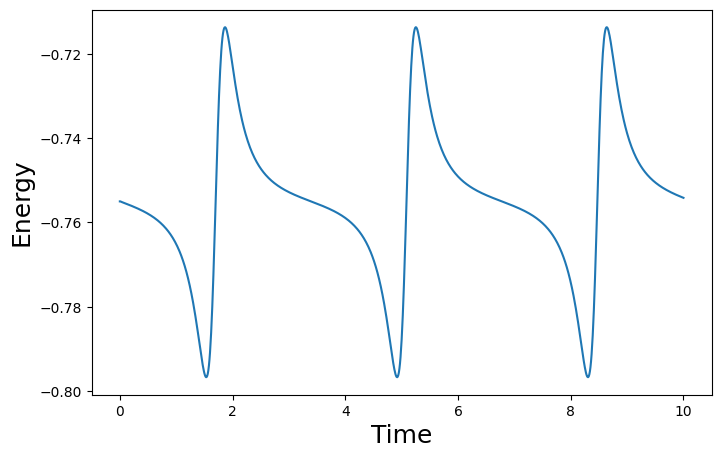

In [11]:
## !!! Or visually, with energy-time plot !!! ###

fig, ax = plt.subplots(figsize=(8,5))

ax.plot(time,energy) 
ax.set_xlabel("Time", fontsize=18);
ax.set_ylabel("Energy", fontsize=18);
plt.show()


## <span style="color:red">Q8</span>
### Convert the non-dimensional period obtained in Question 7, above, into years. How does your result compare with the experimental estimate of between 75-76 years?

You should use the values of the constants $1~\text{au}=1.5\times 10^{11}$ m, $G = 6.67\times 10^{-11}$ kg$^{-1}$m$^3$s$^{-2}$, $M_{\odot}=1.99\times 10^{30}$ kg.

Give a brief comment.

## <span style="color:red">Answer</span>

The timescale in the problem is ts = L³/2s/(GM)¹/², so the dimensional period is 473.5ts ≈ 75.7 years (computed using code below):

In [7]:
AU = 1.5e+11  # 1 AU in m
G = 6.67e-11  # Gravitational constant in SI units
M = 1.99e+30  # Solar mass in kg

period_years = Pest * np.sqrt(AU**3/(G*M)) / (86400 * 365.25)
print(f'Estimate of period (years): {period_years}')

Estimate of period (years): 75.61347812746631


This is within the period experimentally observed range of 75 − 76 years.

**Marking notes**

- 1 point: a clear explanation (ideally with workings), the period of ~75.6 years is mentioned, and an agreement with the experiment is discussed. Don't take off points if the working is not included, as we didn't ask for it in the task.

- 0.5 points: explanation and discussion in the right diretion, but the period provided is different from 75.6

  
- 0 points: incorrect or missing